In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
df = pd.read_csv("healthcare_dataset_10k.csv")

df.head()

,Patient_ID,Age,Gender,Department,Diagnosis,Insurance_Type,Admission_Date,Discharge_Date,Length_of_Stay,Treatment_Cost,Readmitted
0,100000,69,Male,Oncology,Stroke,Government,2025-09-30 15:06:48.582736,2025-10-03 15:06:48.582736,3,197216,No
1,100001,32,Male,Oncology,Cancer,Self-Pay,2025-03-12 15:06:48.582736,2025-03-26 15:06:48.582736,14,106552,No
2,100002,89,Female,Orthopedics,Fracture,Private,2025-12-24 15:06:48.582736,2026-01-02 15:06:48.582736,9,50363,No
3,100003,78,Male,Orthopedics,Infection,Self-Pay,2025-11-22 15:06:48.582736,2025-12-03 15:06:48.582736,11,109899,No
4,100004,38,Female,Neurology,Infection,Self-Pay,2025-02-28 15:06:48.582736,2025-03-14 15:06:48.582736,14,172652,No


In [6]:
#shape of data 
df.shape

(10000, 11)

In [9]:
# data types 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      10000 non-null  int64 
 1   Age             10000 non-null  int64 
 2   Gender          10000 non-null  object
 3   Department      10000 non-null  object
 4   Diagnosis       10000 non-null  object
 5   Insurance_Type  10000 non-null  object
 6   Admission_Date  10000 non-null  object
 7   Discharge_Date  10000 non-null  object
 8   Length_of_Stay  10000 non-null  int64 
 9   Treatment_Cost  10000 non-null  int64 
 10  Readmitted      10000 non-null  object
dtypes: int64(4), object(7)
memory usage: 859.5+ KB


In [10]:
#null values 
df.isnull().sum()

Patient_ID        0
Age               0
Gender            0
Department        0
Diagnosis         0
Insurance_Type    0
Admission_Date    0
Discharge_Date    0
Length_of_Stay    0
Treatment_Cost    0
Readmitted        0
dtype: int64

In [11]:
# BASIC STATS 
df.describe()

,Patient_ID,Age,Length_of_Stay,Treatment_Cost
count,10000.00000,10000.000000,10000.000000,10000.000000
mean,104999.50000,53.539700,7.947200,104709.174500
std,2886.89568,20.757324,4.291556,54979.556623
min,100000.00000,18.000000,1.000000,10010.000000
25%,102499.75000,36.000000,4.000000,61526.000000
50%,104999.50000,53.000000,8.000000,97337.500000
75%,107499.25000,72.000000,12.000000,143020.000000
max,109999.00000,89.000000,15.000000,249971.000000


In [17]:
# CATEGORY DISTRIBUTION 
print(df['Gender'].value_counts())

Gender
Female    5072
Male      4928
Name: count, dtype: int64


In [20]:
print(df["Department"].value_counts())
print(df["Insurance_Type"].value_counts())
print(df["Readmitted"].value_counts())

Department
General Medicine    2069
Oncology            2031
Cardiology          1986
Orthopedics         1967
Neurology           1947
Name: count, dtype: int64
Insurance_Type
Government    3452
Self-Pay      3302
Private       3246
Name: count, dtype: int64
Readmitted
No     8041
Yes    1959
Name: count, dtype: int64


In [21]:
# correaltion check 
numeric_df = df.select_dtypes(include = ['int64' , 'float64'])
corr_matrix = numeric_df.corr()
corr_matrix

,Patient_ID,Age,Length_of_Stay,Treatment_Cost
Patient_ID,1.000000,0.014168,0.005073,0.004373
Age,0.014168,1.000000,0.007770,0.008531
Length_of_Stay,0.005073,0.007770,1.000000,-0.008746
Treatment_Cost,0.004373,0.008531,-0.008746,1.000000


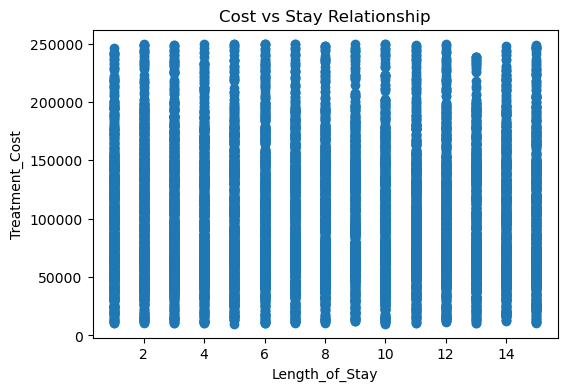

In [24]:
# Cost vs Stay Relationship
plt.figure(figsize=(6,4))
plt.scatter(df['Length_of_Stay'], df['Treatment_Cost'])
plt.xlabel("Length_of_Stay")
plt.ylabel("Treatment_Cost")
plt.title("Cost vs Stay Relationship")
plt.show()

In [29]:
#Age vs Readmission Analysis
df['Age_Group'] = pd.cut(df['Age'],
                         bins=[0,30,50,70,100],
                         labels=['Young','Adult','Senior','Elderly'])
df['Age_Group']

0        Senior
1         Adult
2       Elderly
3       Elderly
4         Adult
         ...   
9995    Elderly
9996      Adult
9997     Senior
9998     Senior
9999      Adult
Name: Age_Group, Length: 10000, dtype: category
Categories (4, object): ['Young' < 'Adult' < 'Senior' < 'Elderly']

In [32]:

df['Readmitted_Numeric'] = df['Readmitted'].map({'Yes': 1, 'No': 0})


readmission_rate = df.groupby('Age_Group', observed=True)['Readmitted_Numeric'].mean() * 100

print(readmission_rate)

Age_Group
Young      16.393443
Adult      14.822620
Senior     19.520295
Elderly    26.851159
Name: Readmitted_Numeric, dtype: float64


In [4]:
# 4️⃣ High-Risk Segmentation
#high cost + long stay 
avg_cost = df['Treatment_Cost'].mean()
avg_stay = df['Length_of_Stay'].mean()
segment_a = df[(df['Treatment_Cost'] > avg_cost) & 
               (df['Length_of_Stay'] > avg_stay)]

segment_a.shape

(2417, 11)

In [5]:
#High Cost + Readmitted
segment_b = df[(df['Treatment_Cost'] > avg_cost) & ( df['Readmitted'] == 1 )]
segment_b 


,Patient_ID,Age,Gender,Department,Diagnosis,Insurance_Type,Admission_Date,Discharge_Date,Length_of_Stay,Treatment_Cost,Readmitted


In [7]:
#Top 10% Spenders
threshold = df['Treatment_Cost'].quantile(0.90)
top_10 = df[df['Treatment_Cost'] >= threshold ]
top_10 

,Patient_ID,Age,Gender,Department,Diagnosis,Insurance_Type,Admission_Date,Discharge_Date,Length_of_Stay,Treatment_Cost,Readmitted
0,100000,69,Male,Oncology,Stroke,Government,2025-09-30 15:06:48.582736,2025-10-03 15:06:48.582736,3,197216,No
11,100011,55,Male,Oncology,Diabetes,Self-Pay,2025-04-06 15:06:48.582736,2025-04-18 15:06:48.582736,12,231343,No
23,100023,32,Female,Oncology,Infection,Private,2025-04-12 15:06:48.582736,2025-04-19 15:06:48.582736,7,192992,No
31,100031,20,Female,Oncology,Stroke,Government,2025-06-08 15:06:48.582736,2025-06-10 15:06:48.582736,2,235365,No
47,100047,64,Female,Oncology,Fracture,Private,2025-12-22 15:06:48.582736,2025-12-24 15:06:48.582736,2,197960,No
...,...,...,...,...,...,...,...,...,...,...,...
9968,109968,66,Male,Oncology,Heart Disease,Private,2025-05-18 15:06:48.582736,2025-06-02 15:06:48.582736,15,204865,No
9985,109985,72,Female,Cardiology,Cancer,Private,2025-08-07 15:06:48.582736,2025-08-13 15:06:48.582736,6,189510,Yes
9994,109994,63,Female,Oncology,Infection,Private,2025-06-27 15:06:48.582736,2025-07-02 15:06:48.582736,5,249255,Yes
9995,109995,88,Female,Cardiology,Heart Disease,Private,2025-04-06 15:06:48.582736,2025-04-08 15:06:48.582736,2,192856,No


📊 Final Insights – Healthcare Data Analysis
🔹 1. No Strong Linear Correlation

Correlation analysis showed no significant linear relationship between age, length of stay, and treatment cost, indicating cost variation is influenced more by categorical or random factors in this dataset.

🔹 2. Cost vs Stay Pattern

Grouped analysis of length of stay did not show a consistent increase in treatment cost, suggesting cost is not strictly dependent on hospital stay duration in this dataset.

🔹 3. Age vs Readmission

Readmission rates were compared across age groups to identify risk patterns. (Yaha apna actual % likhna.)

Example:

Elderly patients showed relatively higher readmission rates compared to younger groups.

🔹 4. High-Risk Segmentation

Top 10% of patients contributed disproportionately to total revenue, indicating revenue concentration among high-spending patients.

(Actual % likhna yaha)

🔹 5. Business Recommendation

Focus monitoring on high-cost patients.

Implement targeted care programs for high readmission age groups.

Track long-stay patients for cost optimization.